In this Notebook, we want to create empirical Derrida plots. These are plots that relate the current normalised Hamming distance between two initial configurations (horizontal axis) to the normalised Hamming distance of those configurations in the next time step (vertical axis). If the resulting data point in the scatter plot is above the first diagonal, the Hamming distance is increasing (the damage is spreading). Otherwise, the damage remains the same, or even shrinks. Especially interesting is the behaviour around the origin, which is a measure for the sensitivity to initial conditions. The slope of the linear fit through the first couple of points close to the origin is called the Derrida coefficient.

IMPORTANT: the Derrida coefficient is related to the slope, but is not EQUAL to the slope! See for example "On Creativity of Elementary Cellular Automata" by Adamatzky et al. Try to read and understand the original Derrida paper ("Evolution of overlaps between con gurations in random Boolean networks")

In this notebook we will
1. [CHECK] Define a function that creates two pairs of arrays that can be used to plot the Derrida plot
2. Define a function that can use these arrays to output a single Derrida coefficient
3. Define a function that can output the equivalent rule for isomorphically defined LLNAs, and use this function to create a subset of non-equivalent rules.
4. For all non-equivalent rules of a particular resolution, and for a particular network, create a plot that relates the Derrida coefficient with genotype parameters (Hamming weight and Boolean sensitivity). Note that we should only run over non-equivalent rules.
    - The hope is that the Boolean sensitivity will correlate with the Derrida coefficient.
5. For a number of particularly interesting rules, consider the influence of a network parameter on the Derrida coefficient.
    - We expect to see a sort of phase change when a particular average neighbourhood size is reached.

Remaining questions and further research topics are listed below:
- Can we make an analytical approximation of the Derrida plot and/or coordinate?
- What is the relationship with the Jacobian and other established methods?
- How does the Derrida coefficient relate to the mu sensitivity (which is not the same as the Boolean sensitivity after all)
- I should add the possiblity of choosing the order of the nodes that are being affected by the defect! In that way, I can compare what happens to the overall behaviour if you change states in nodes with high PageRank (for example) first, compared to low PageRank first. Right now, random nodes are being chosen every time.
- Perhaps I could make a Derrida plot counterpart for networks, where I look at the evolution of the size of the affected subgraph (?)
- Instead of the slope of the linear fit, I could look at the angle (0 to 90) and normalise it to 0 to 1. Not sure how useful that would be, though.
- I should compare the Derrida coefficient with (at least) the Shannon entropy, the word length distribution (calculated on whole diagram), and the Lempel-Ziv complexity.

# 1. Function that creates the Derrida arrays

In [13]:
# standard preamble for the Notebooks I use

import torch as tc
import igraph as ig
import numpy as np
from numpy.typing import NDArray
from matplotlib import pyplot as plt
from matplotlib import rcParams
import math

from typing import Optional, Tuple, Union, Sequence

# Enable LaTeX and set Times New Roman as the font
rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "text.latex.preamble": r"\usepackage{amsmath}"  # Optional: Use LaTeX packages
})

from tqdm import tqdm

import sys, os
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

from src.automata import LLNA
from src.simulation import *
from src.analysis import get_derrida_arrays

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


(<Figure size 1000x180 with 1 Axes>,
 <Axes: title={'center': 'Diagram for LLNA $R_{3}B_{6}S_{1}$'}, xlabel="State density $\\rho$ of the node's neighbourhood", ylabel='Node becomes ...'>)

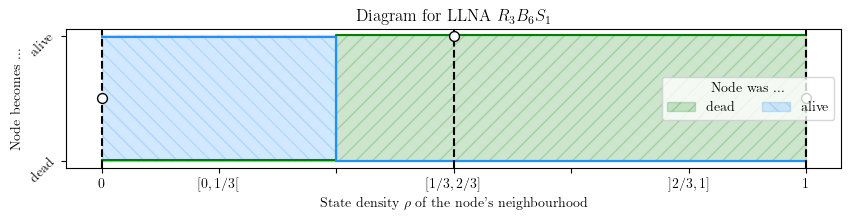

In [10]:
# Let's consider the Hamming weight and the Boolean sensitivity over two very different networks
num_nodes = 1000  # Number of nodes
num_edges_per_new_node = 3  # Number of edges each new node adds

# Generate Scale-Free Network (Barabási–Albert Model)
# ba_graph = ig.Graph.Barabasi(n=num_nodes, m=num_edges_per_new_node, directed=False)
ring_graph = ig.Graph.Ring(num_nodes)

resolution = 3
# born_if = [1]
# survive_if = [0,2]
# model = LLNA(resolution, x=born_if, y=survive_if, iso=True)
model = LLNA(resolution, iso=True)

model.diagram(degree=2, plot_dist=True)

100%|██████████| 1/1 [00:02<00:00,  2.54s/it]


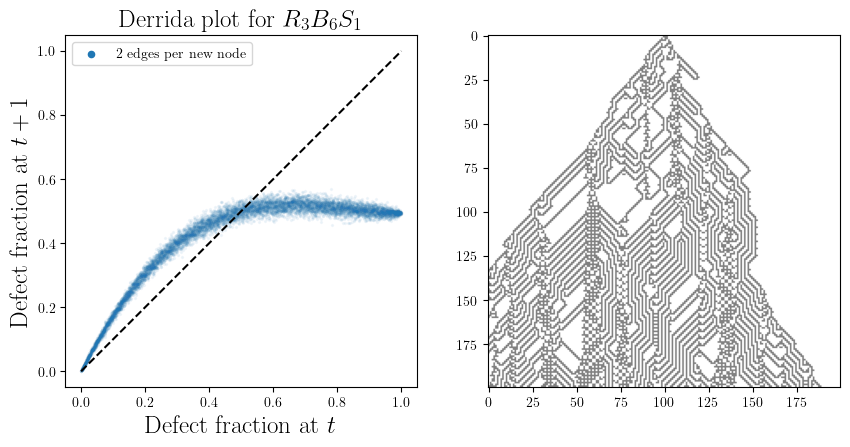

In [11]:
points_per_rho = 10

num_nodes = 1000  # Number of nodes
num_edges_per_new_node_list = [2] #, 4, 6, 8, 10]  # Number of edges each new node adds

# init_config = np.zeros(num_nodes)
init_config = np.random.randint(0, 2, size=num_nodes)

inputs_list = []
outputs_list = []
for num_edges_per_new_node in tqdm(num_edges_per_new_node_list, total=len(num_edges_per_new_node_list)):
    # Generate Scale-Free Network (Barabási–Albert Model)
    # ba_graph = ig.Graph.Barabasi(n=num_nodes, m=num_edges_per_new_node, directed=False)
    ring_graph = ig.Graph.Ring(num_nodes)
    inputs, outputs = get_derrida_arrays(ring_graph, model, points_per_rho=points_per_rho, init_config=init_config)
    inputs_list.append(inputs)
    outputs_list.append(outputs)

# find TEP for comparison
ring_graph.to_directed()
edges = tc.tensor(ring_graph.get_edgelist()).T
ring_graph.to_undirected()
H = np.array(model.forward(edges, tc.tensor(init_config[np.newaxis,:]), T=num_nodes-1), dtype=int)

edge_def_idx = 100
init_config_def = init_config.copy()
init_config_def[edge_def_idx] = 1-init_config_def[edge_def_idx]
H_def = np.array(model.forward(edges, tc.tensor(init_config_def[np.newaxis,:]), T=num_nodes-1), dtype=int)

# figure
fig, axs = plt.subplots(1,2,figsize=(10,5))
fontsize=18
alpha=0.05
axs[0].plot([0, 1], [0, 1], 'k--')
for inputs, outputs, num_edges_per_new_node in zip(inputs_list, outputs_list, num_edges_per_new_node_list):
    axs[0].scatter(inputs, outputs, alpha=alpha, s=2, label=fr"{num_edges_per_new_node} edges per new node")

axs[0].set_title(fr"Derrida plot for {model.__str__(latex=True)}", fontsize=fontsize)
axs[0].set_xlabel(fr"Defect fraction at $t$", fontsize=fontsize)
axs[0].set_ylabel(fr"Defect fraction at $t+1$", fontsize=fontsize)

legend = axs[0].legend()
for handle in legend.legend_handles:
    handle.set_alpha(1)  # Set marker transparency in legend
    handle.set_sizes([20])  # Change marker size in legend

axs[0].set_aspect(1)
axs[0].set_xlim([-0.05, 1.05])
axs[0].set_ylim([-0.05, 1.05])

# show cropped version of TEP
# axs[1].imshow(H[0, :edge_def_idx*2, :edge_def_idx*2])
axs[1].imshow((H[0, :edge_def_idx*2, :edge_def_idx*2] + H_def[0, :edge_def_idx*2, :edge_def_idx*2]) % 2, cmap='Greys', alpha=0.5)


In [15]:
# Define a function that identifies equivalent update rule
def return_equivalent_rule(resolution:int, B_set:Union[NDArray[np.int_], Sequence[int]], S_set:Union[NDArray[np.int_], Sequence[int]]) -> Tuple[NDArray[np.int_], NDArray[np.int_]]:
    """
    A function that returns the beta and sigma integer of the equivalent local update rule.

    Parameters
    ----------
    resolution : int
        Positive integer indicating the resolution of the local update rule.
    B_set : list or numpy.ndarray
        list of integers corresponding to the indices of the activated density intervals in the B set.
    S_set : list or numpy.ndarray
        list of integers corresponding to the indices of the activated density intervals in the B set.

    Returns
    -------
    B_set_equiv : list or numpy.ndarray
        list of integers corresponding to the indices of the activated density intervals in the B set of the equivalent rule.
    S_set_equiv : list or numpy.ndarray
        list of integers corresponding to the indices of the activated density intervals in the B set of the equivalent rule.
    """
    # make sure the sets are numpy.ndarray
    B_set = np.asarray(B_set, dtype=int)
    S_set = np.asarray(S_set, dtype=int)
    # mirror the sets
    B_set_mirror = resolution - 1 - B_set
    S_set_mirror = resolution - 1 - S_set
    # complement the sets
    B_set_mirror_comp = np.setdiff1d(np.arange(resolution), B_set_mirror)
    S_set_mirror_comp = np.setdiff1d(np.arange(resolution), S_set_mirror)
    # switch up the sets
    B_set_equiv = S_set_mirror_comp
    S_set_equiv = B_set_mirror_comp
    return B_set_equiv, S_set_equiv
    

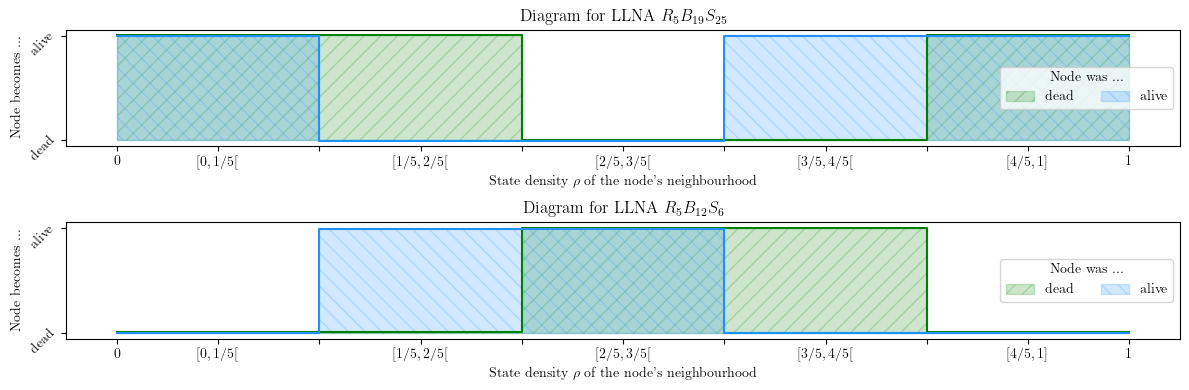

In [22]:
resolution = 5
model = LLNA(resolution)
B_set, S_set = model.rule

B_set_equiv, S_set_equiv = return_equivalent_rule(resolution, B_set, S_set)
model_equiv = LLNA(resolution, x=B_set_equiv, y=S_set_equiv)

fig, axs = plt.subplots(2,1, figsize=(12,4))
model.diagram(ax=axs[0])
model_equiv.diagram(ax=axs[1])

fig.tight_layout()